In [ ]:
#first of all, import the needed libraries
import pandas as pd
import matplotlib.pyplot as plt


#load the datasets and create a copy to work on

#in the first two datasets ";" were used as a separator, while "," were used in the third.
symbols_raw=pd.read_csv("data/symbols.csv",sep=";")
symbols=symbols_raw.copy()

transactions_raw=pd.read_csv("data/account-statement-1-1-2024-12-31-2024.csv",sep=";")
transactions=transactions_raw.copy()

countries_raw=pd.read_csv("data/country.csv")
countries=countries_raw.copy()




#check for missing values in the datasets

#visualization of missing values in symbols dataset
print("---NA SYMBOLS---")
print(symbols.isnull().sum())

#missing values in transactions
print("---NA TRANSACTIONS---")
print(transactions.isnull().sum())
#in this case there were some missing values for all the columns in the last observations, making up a 
# completely empty part of the dataset, for this reason they were deleted
transactions=transactions.dropna(subset=["IDTransaction", "Date"], how="all")
#moreover, at the end of the dataset there is an unnamed column, that also contains no
#observations, so also that column is deleted to avoid further problems
transactions=transactions.drop(columns=["Unnamed: 5"])
print("---DEFINITIVE NA TRANSACTIONS---")
print(transactions.isnull().sum())

#visualization of missing values in countries dataset
print("---NA COUNTRIES---")
print(countries.isna().sum())


#validate symbols: this code allows to check if every symbol in the transaction
#dataset also exists in the symbol dataset: in particular eventual missing symbols
#get printed as an output.
missing_symbols=(set(transactions["Symbol"])-set(symbols["symbol"]))
print("---MISSING SYMBOLS IN THE SYMBOLS DATASET")
print(missing_symbols)


#validate countries
missing_countries=(set(symbols["country"])-set(countries["name"]))
print("---MISSING COUNTRIES IN THE COUNTRIES DATASET---")
print(missing_countries)

#since there were symbols and countries not present in those tables, such values
#were deleted, in order to maintain referential integrity
transactions=transactions[transactions["Symbol"].isin(symbols["symbol"])]

symbols=symbols[symbols["country"].isin(countries["name"])]




#CREATION OF DIMENSIONS


#creation of the table dim_time

#first of all, the date column gets converted from string format into a real datetime object
transactions["Date"]=pd.to_datetime(transactions["Date"],dayfirst=True)

#creation of the dimension table
dim_time=pd.DataFrame({"date":transactions["Date"]}).drop_duplicates()

#extract day, month, quarter and year
dim_time["day"]=dim_time["date"].dt.day
dim_time["month"]=dim_time["date"].dt.month
dim_time["quarter"]=dim_time["date"].dt.quarter
dim_time["year"]=dim_time["date"].dt.year

#resetting the index and discarding the old one, instead of keeping it as a column
dim_time=dim_time.reset_index(drop=True)

#creation of the surrogate key to use in the fact table (starts from 1 instead of 0)
dim_time["time_key"]=dim_time.index+1

#keep only the relevant columns and reorder the columns into a clear format
dim_time=dim_time[["time_key", "year", "month", "day", "quarter", "date"]]



#creation of dim_geography

#take only the relevant columns for countries and drop eventual duplicates
dim_geography=countries[["name","region","sub-region"]].drop_duplicates()

#reset the index
dim_geography=dim_geography.reset_index(drop=True)
#create the surrogate key to use in the fact table (starts from 1 instead of 0)
dim_geography["geography_key"]=dim_geography.index+1

#reorder the columns into a clear format
dim_geography=dim_geography[["geography_key","name","region","sub-region"]]



#creation of dim_transactiontype

#extract all unique transaction types
dim_transaction_type=pd.DataFrame({"transaction_type":transactions["TransactionType"].unique()})

#reset the index
dim_transaction_type=dim_transaction_type.reset_index(drop=True)
#create the surrogate key to use in the fact table (starts from 1 instead of 0)
dim_transaction_type["transaction_type_key"]=dim_transaction_type.index+1

#keep only the relevant columns
dim_transaction_type=dim_transaction_type[["transaction_type_key","transaction_type"]]



#creation of dim_symbol

#take only the relevant columns and drop eventual duplicates
dim_symbol=symbols[["symbol","company_name","sector","industry","country"]].drop_duplicates()

#reset the index
dim_symbol=dim_symbol.reset_index(drop=True)
#create a surrogate key to use in the fact table (starts with 1 instead of 0)
dim_symbol["symbol_key"]=dim_symbol.index+1

#order the columns properly
dim_symbol=dim_symbol[["symbol_key","symbol","company_name","sector","industry","country"]]







#CREATION OF THE FACT TABLE

#create a copy of the transactions table
fact=transactions.copy()
#join the fact table to symbol dimension
fact=fact.merge(dim_symbol[["symbol_key","symbol","country"]], left_on="Symbol", right_on="symbol", how="left")
#join the fact table to time dimension
fact=fact.merge(dim_time[["time_key","date"]],left_on="Date",right_on="date",how="left")
#join the fact table to transaction type dimension
fact=fact.merge(dim_transaction_type, left_on="TransactionType",right_on="transaction_type",how="left")
#join the fact table to geography dimension
fact=fact.merge(dim_geography[["geography_key","name"]],left_on="country",right_on="name",how="left")

#create the fact table that contains only its degenerate key(IDTransaction), foreign keys and its measure(Unit)
fact_transactions=fact[["IDTransaction","time_key","symbol_key","geography_key","transaction_type_key","Unit"]]

---NA SYMBOLS---
symbol          0
company_name    0
sector          0
industry        0
country         0
dtype: int64
---NA TRANSACTIONS---
IDTransaction       464
Date                464
TransactionType     464
Symbol              464
Unit                464
Unnamed: 5         2745
dtype: int64
---DEFINITIVE NA TRANSACTIONS---
IDTransaction      0
Date               0
TransactionType    0
Symbol             0
Unit               0
dtype: int64
---NA COUNTRIES---
name                          0
alpha-2                       1
alpha-3                       0
country-code                  0
iso_3166-2                    0
region                        2
sub-region                    2
intermediate-region         144
region-code                   2
sub-region-code               2
intermediate-region-code    144
dtype: int64
---MISSING SYMBOLS IN THE SYMBOLS DATASET
{'IBE', 'WF', 'HTGC', 'OBDC', 'UCG', 'AZM', 'AGO.l', 'ARCH', 'MONC', 'TKC', 'MFG', 'CCAP', 'RCMT', 'FNC', 'VWS', 'CSIQ', 'RI

In [3]:
#create a unique de-normalized table to use for solving the queries

#creating a separate copy of the fact table to work on
fact_enriched=fact_transactions.copy()

#joining the de-normalized table with time dimension using the time key
fact_enriched=fact_enriched.merge(dim_time,on="time_key",how="left")
#joining the de-normalized table with symbol dimension using the symbol key
fact_enriched=fact_enriched.merge(dim_symbol,on="symbol_key",how="left")
#joining the de-normalized table with geography dimension using the geography key
fact_enriched=fact_enriched.merge(dim_geography,on="geography_key",how="left")
#joining the de-normalized table with transaction type dimension using the transaction type key
fact_enriched=fact_enriched.merge(dim_transaction_type,on="transaction_type_key",how="left")

#select only the columns needed for the analysis and re-order them
fact_enriched=fact_enriched[["symbol","company_name","sector","industry","transaction_type","Unit","country","region","sub-region","year","month","day","quarter"]]

In [4]:
#getting an overall view of the de-normalized table
fact_enriched.head(10)

,symbol,company_name,sector,industry,transaction_type,Unit,country,region,sub-region,year,month,day,quarter
0,BAP,Credicorp Ltd.,Financial Services,Banks - Regional,BUY,1605.0,Peru,Americas,Latin America and the Caribbean,2024,1,11,1
1,BAP,Credicorp Ltd.,Financial Services,Banks - Regional,SELL,1605.0,Peru,Americas,Latin America and the Caribbean,2024,1,24,1
2,BAP,Credicorp Ltd.,Financial Services,Banks - Regional,SELL,914.0,Peru,Americas,Latin America and the Caribbean,2024,1,10,1
3,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,BUY,646.0,Bermuda,Americas,Northern America,2024,1,16,1
4,ALVO,Alvotech,Healthcare,Drug Manufacturers - Specialty & Generic,SELL,646.0,Luxembourg,Europe,Western Europe,2024,1,16,1
5,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,BUY,519.0,Bermuda,Americas,Northern America,2024,1,30,1
6,ALVO,Alvotech,Healthcare,Drug Manufacturers - Specialty & Generic,SELL,519.0,Luxembourg,Europe,Western Europe,2024,1,31,1
7,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,BUY,515.0,Bermuda,Americas,Northern America,2024,1,31,1
8,ALVO,Alvotech,Healthcare,Drug Manufacturers - Specialty & Generic,SELL,515.0,Luxembourg,Europe,Western Europe,2024,2,5,1
9,ACGL,Arch Capital Group Ltd.,Financial Services,Insurance - Diversified,BUY,320.0,Bermuda,Americas,Northern America,2024,1,11,1


TOP 5 SECTORS BY NUMBER OF SELL TRANSACTIONS IN THE US DURING 2024
sector
Technology                158
Communication Services     58
Financial Services         55
Healthcare                 50
Consumer Cyclical          48
Name: Unit, dtype: int64


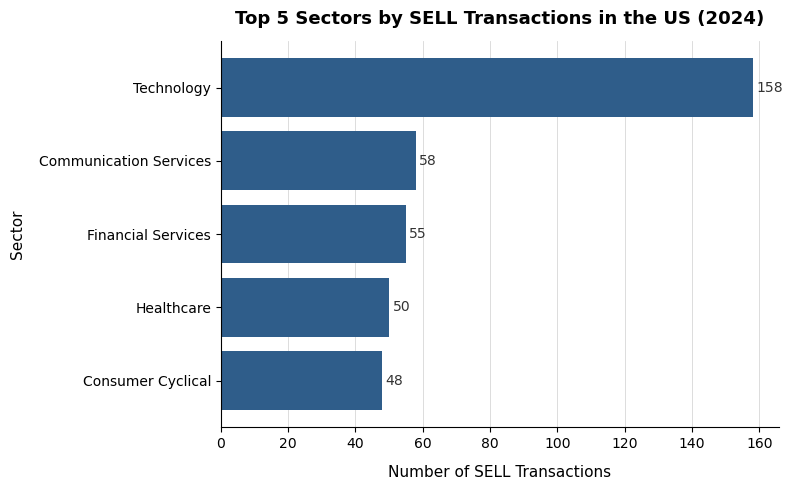

In [5]:
#1)WHAT ARE THE TOP 5 SECTORS BY NUMBER OF SELL TRANSACTIONS IN US DURING 2024?

#filter the denormalized dataset for the sell transactions, which took place in 2024 in the USA.
#After that drop eventual observations with na in the sector attribute and group by sector.
#on the obtained groups compute the sum of units traded, sort values in descending order and get 
#the first five observations (corresponding to the actual top5)
top5_sell=fact_enriched[
    (fact_enriched["transaction_type"]=="SELL")&
    (fact_enriched["year"]==2024)&
    (fact_enriched["country"]=="United States of America")
     ].dropna(subset=["sector"]).groupby("sector")["Unit"].count().sort_values(ascending=False).head(5)

print("TOP 5 SECTORS BY NUMBER OF SELL TRANSACTIONS IN THE US DURING 2024")
print(top5_sell)

#convert to dataframe for easier plotting
top5_sell_df=top5_sell.reset_index()
top5_sell_df.columns=["sector", "transactions"]

#create the figure
plt.figure(figsize=(8, 5))
ax=plt.gca()

#create the horizontal bar chart
bars=ax.barh(top5_sell_df["sector"],top5_sell_df["transactions"],color="#2F5D8A")

#invert y-axis to get the highest value on top
ax.invert_yaxis()

#set labels and title
ax.set_xlabel("Number of SELL Transactions",fontsize=11,labelpad=10)
ax.set_ylabel("Sector",fontsize=11,labelpad=10)
ax.set_title("Top 5 Sectors by SELL Transactions in the US (2024)",fontsize=13,pad=12,weight="bold")

#removing spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


#adding a vertical grid
ax.set_axisbelow(True)
ax.grid(axis="x",linewidth=0.6,alpha=0.5)

#creating a function to add value labels on bars
def add_bar_labels(ax,bars,orientation="h",offset=1,fontsize=10,color="#333333"):

    for bar in bars:

        #for graphs with vertical orientation
        if orientation=="v":
            value=bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2,value+offset, f"{int(value)}",ha="center",fontsize=fontsize,color=color)


        #for charts with horizontal orientation
        else:
            width=bar.get_width()
            ax.text(width+offset, bar.get_y()+bar.get_height()/2, f"{int(width)}",va="center",fontsize=fontsize,color=color)


add_bar_labels(ax,bars)

plt.tight_layout()
plt.show()

RANK OF THE QUARTERS OF 2024 BY TOTAL NUMBER OF TRANSACTIONS
quarter
1    999
2    542
3    268
4    260
Name: Unit, dtype: int64


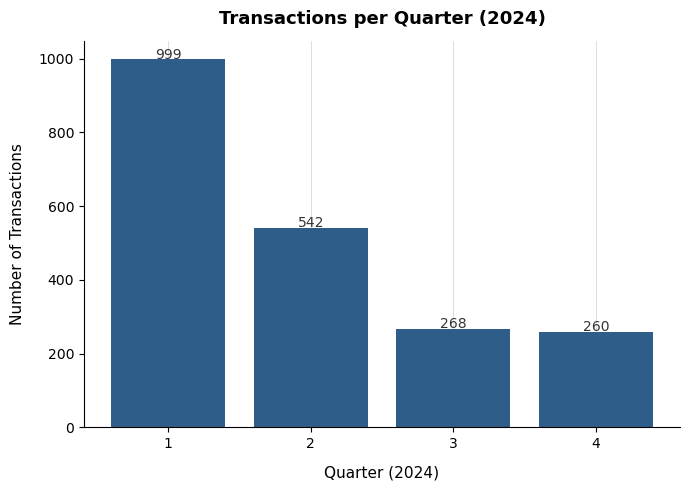

In [ ]:
#3)RANK ALL QUARTERS OF 2024 BY TOTAL NUMBER OF TRANSACTIONS (BUY+SELL)

#filter the denormalized dataset for the transactions, which took place in 2024.
#After that drop eventual observations with na in the quarter attribute and group by quarter.
#on the obtained groups compute the count of transaction operations that took place, sort values 
# in descending order and get the overall ranking by quarter.
quarter_rank=fact_enriched[
    (fact_enriched["year"]==2024)
].dropna(subset=["quarter"]).groupby("quarter")["Unit"].count().sort_values(ascending=False)

print("RANK OF THE QUARTERS OF 2024 BY TOTAL NUMBER OF TRANSACTIONS")
print(quarter_rank)

#convert series to dataframe for easier plotting
quarter_rank_df=quarter_rank.reset_index()
quarter_rank_df.columns=["quarter", "transactions"]

#sort by quarter
quarter_rank_df=quarter_rank_df.sort_values("quarter")

#setting the figure
plt.figure(figsize=(7, 5))
ax=plt.gca()

#plotting the barchart
bars=ax.bar(quarter_rank_df["quarter"].astype(str),quarter_rank_df["transactions"],
    color="#2F5D8A")


#setting labels and title
ax.set_xlabel("Quarter (2024)",fontsize=11,labelpad=10)
ax.set_ylabel("Number of Transactions",fontsize=11,labelpad=10)
ax.set_title("Transactions per Quarter (2024)",fontsize=13,pad=12,weight="bold")

#removing spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


#adding a vertical grid
ax.set_axisbelow(True)
ax.grid(axis="x",linewidth=0.6,alpha=0.5)

#adding value labels on top of bars
add_bar_labels(ax,bars,orientation="v")

plt.tight_layout()
plt.show()

TOP 5 COUNTRIES BY NUMBER OF UNITS TRADED IN FINANCIAL SERVICE COMPANIES
country
United States of America    7352
Peru                        4434
Bermuda                     3658
China                       1663
Canada                      1466
Name: Unit, dtype: int64


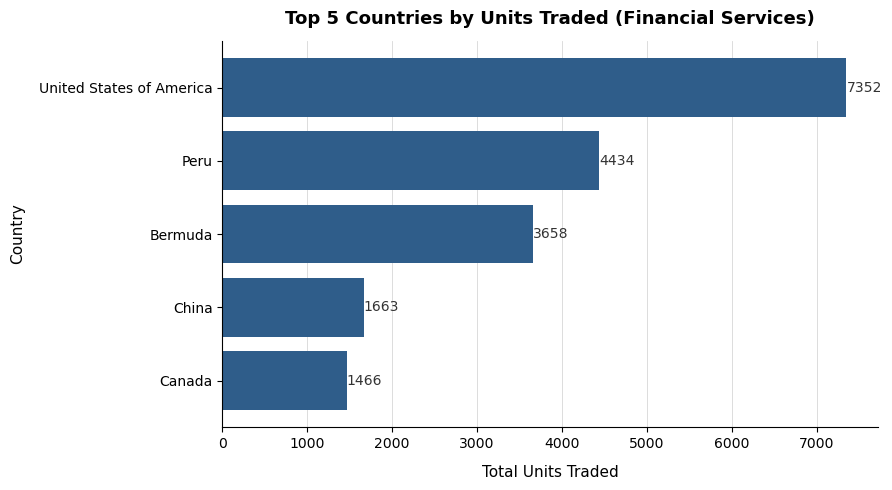

In [7]:
#8)WHAT ARE THE TOP 5 COUNTRIES BY NUMBER OF UNITS TRADED IN FINANCIAL SERVICE COMPANIES

#filter the denormalized dataset for the financial services sector.
#After that drop eventual observations with na in the country attribute and group by country.
#on the obtained groups compute the sum of units traded, sort values in descending order and get 
#the first five observations (corresponding to the actual top5)
top5_countries_fs=fact_enriched[
    (fact_enriched["sector"]=="Financial Services")
].dropna(subset=["country"]).groupby("country")["Unit"].sum().astype(int).sort_values(ascending=False).head(5)


print("TOP 5 COUNTRIES BY NUMBER OF UNITS TRADED IN FINANCIAL SERVICE COMPANIES")
print(top5_countries_fs)

#convert series to dataframe
top5_countries_fs_df=top5_countries_fs.reset_index()
top5_countries_fs_df.columns=["country", "units"]

#sort for better ranking
top5_countries_fs_df=top5_countries_fs_df.sort_values("units")

#create the figure
plt.figure(figsize=(9, 5))
ax=plt.gca()

#create the horizontal barchart
bars=ax.barh(top5_countries_fs_df["country"],top5_countries_fs_df["units"],
    color="#2F5D8A")

#add labels and title
ax.set_xlabel("Total Units Traded",fontsize=11,labelpad=10)
ax.set_ylabel("Country",fontsize=11,labelpad=10)
ax.set_title("Top 5 Countries by Units Traded (Financial Services)",fontsize=13,pad=12,weight="bold")

#removing spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


#adding a vertical grid
ax.set_axisbelow(True)
ax.grid(axis="x",linewidth=0.6,alpha=0.5)

#adding value labels on top of bars
add_bar_labels(ax,bars)


plt.tight_layout()
plt.show()

TOP 5 COMPANIES BY AVERAGE UNITS PER TRANSACTION IN Q2
company_name
Paysafe Limited                    248.33
HANGZHOU TIGERMED CONSULTING CO    208.50
Alvotech                           206.50
Arch Capital Group Ltd.            206.50
CNH Industrial N.V.                179.33
Name: Unit, dtype: float64


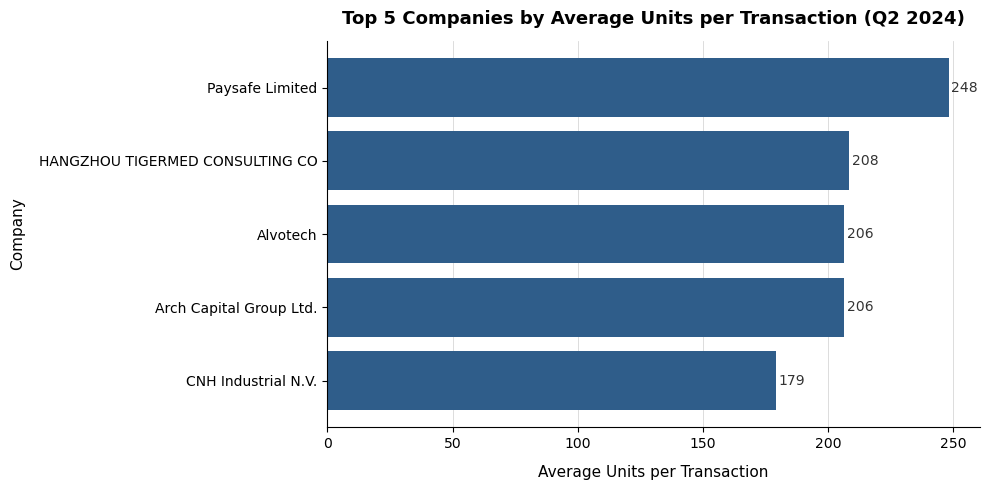

In [8]:
#10)WHAT ARE THE TOP 5 COMPANIES WITH THE HIGHEST AVERAGE UNITS PER TRANSACTION IN Q2

#filter the denormalized dataset for the transactions which took place in 2the second quarter.
#After that drop eventual observations with na in the company name attribute and group by company.
#on the obtained groups compute the average of units traded per each transaction, sort values in descending order and get 
#the first five observations (corresponding to the actual top5)
top5_companies_avg_trans=fact_enriched[
    (fact_enriched["quarter"]==2)
].dropna(subset=["company_name"]).groupby("company_name")["Unit"].mean().round(2).sort_values(ascending=False).head(5)

print("TOP 5 COMPANIES BY AVERAGE UNITS PER TRANSACTION IN Q2")
print(top5_companies_avg_trans)

#convert to dataframe
top5_companies_df=top5_companies_avg_trans.reset_index()
top5_companies_df.columns=["company_name", "avg_units"]

#sort in ascending order
top5_companies_df=top5_companies_df.sort_values("avg_units")

#create the figure
plt.figure(figsize=(10, 5))
ax=plt.gca()

#plot the horizontal barplot
bars=ax.barh(top5_companies_df["company_name"],top5_companies_df["avg_units"],
    color="#2F5D8A")

#set labels and title
ax.set_xlabel("Average Units per Transaction",fontsize=11,labelpad=10)
ax.set_ylabel("Company",fontsize=11,labelpad=10)
ax.set_title("Top 5 Companies by Average Units per Transaction (Q2 2024)",fontsize=13,pad=12,weight="bold")

#removing spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


#adding a vertical grid
ax.set_axisbelow(True)
ax.grid(axis="x",linewidth=0.6,alpha=0.5)

#adding value labels on top of bars
add_bar_labels(ax,bars)


plt.tight_layout()
plt.show()

TOP 10 INDUSTRY-REGION PAIRS BY NUMBER OF TRANSACTIONS IN 2024
industry                        region  
Semiconductors                  Americas    134
Software - Infrastructure       Americas    132
Internet Content & Information  Americas    119
Semiconductors                  Europe      100
Telecom Services                Americas     81
Biotechnology                   Europe       66
Software - Application          Americas     61
Auto Manufacturers              Asia         60
Biotechnology                   Americas     59
Credit Services                 Americas     48
Name: Unit, dtype: int64


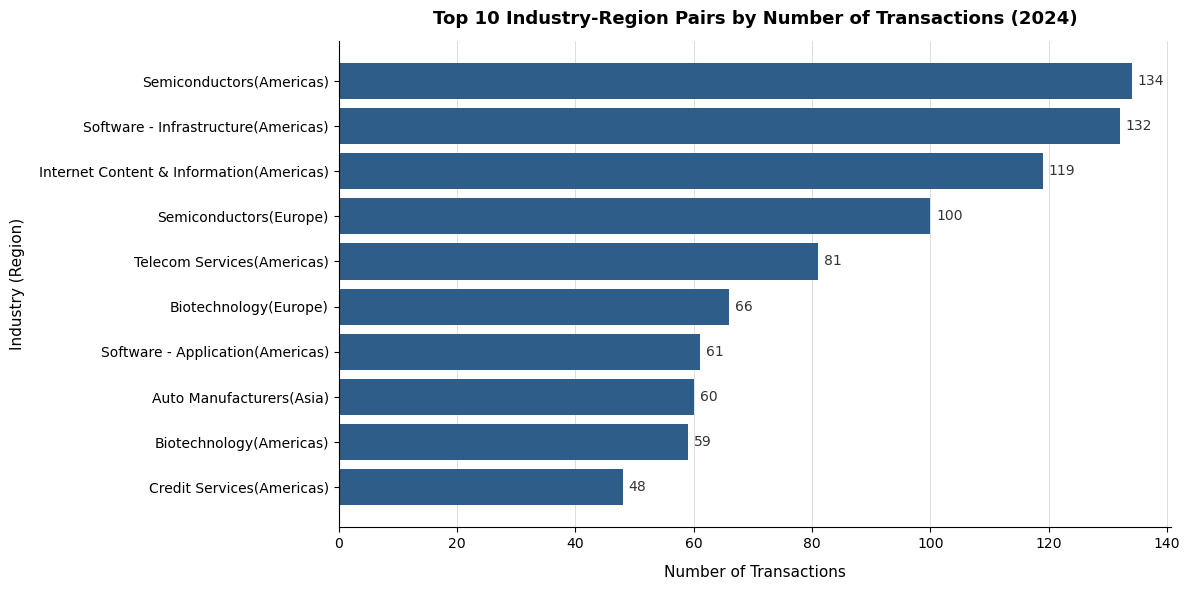

In [9]:
#14)WHAT ARE THE TOP 10 INDUSTRY-REGION PAIRS BY TOTAL NUMBER OF TRANSACTIONS IN 2024

#filter the denormalized dataset for the transactions which took place in 2024.
#After that drop eventual observations with na in the industry and region attributes and group by 
#industry and region.on the obtained groups compute the count of transaction operations that took place,
#sort values in descending order and get the first ten observations (corresponding to the actual top10)
top10_industry_region=fact_enriched[
      (fact_enriched["year"]==2024)
].dropna(subset=["industry","region"]).groupby(["industry","region"])["Unit"].count().sort_values(ascending=False).head(10)

print("TOP 10 INDUSTRY-REGION PAIRS BY NUMBER OF TRANSACTIONS IN 2024")
print(top10_industry_region)

#convert to dataframe
top10_df=top10_industry_region.reset_index()
top10_df.columns=["industry", "region", "transactions"]

#create a combined label
top10_df["industry_region"]=(top10_df["industry"]+ "("+top10_df["region"]+")")

#sort in ascending order
top10_df=top10_df.sort_values("transactions")

#create the figure
plt.figure(figsize=(12, 6))
ax=plt.gca()

#create the horizontal barplot
bars=ax.barh(top10_df["industry_region"],top10_df["transactions"],
    color="#2F5D8A")

#set labels and title
ax.set_xlabel("Number of Transactions",fontsize=11,labelpad=10)
ax.set_ylabel("Industry (Region)",fontsize=11,labelpad=10)
ax.set_title("Top 10 Industry-Region Pairs by Number of Transactions (2024)",fontsize=13,pad=12,weight="bold")

#removing spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


#adding a vertical grid
ax.set_axisbelow(True)
ax.grid(axis="x",linewidth=0.6,alpha=0.5)

#adding value labels on top of bars
add_bar_labels(ax,bars)

plt.tight_layout()
plt.show()

In [10]:
#since the de-normalized table can be used for further analysis, save it as a csv file.
fact_enriched.to_csv("fact_enriched.csv", index=False)